# Notebook 04: Snow Thickness Retrieval

Computes snow thickness from collocated freeboards using
`hs = delta_f / eta_s` where `eta_s = (1 + 0.51*rho_s)^1.5`
following Ulaby et al. (1986) as parameterised in Kwok et al. (2020).
Antarctic baseline: rho_s = 330 kg/m³, eta_s = 1.263.

## 4.1 Setup

In [19]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')
from utils import compute_snow_thickness

OUT_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output'
COL_DIR = f'{OUT_DIR}/collocated'
HS_DIR  = f'{OUT_DIR}/snow_thickness'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(HS_DIR, exist_ok=True)

print('Setup complete')


Setup complete


## 4.2 Load Collocated Data

In [20]:
# Load August 2022 collocated data from Notebook 03
df = pd.read_csv('/g/data/gv90/xl1657/phd/M2_workspace/output/collocated/collocated_202208.csv')
print(f'Loaded {len(df)} matchups')


Loaded 11822 matchups


## 4.3 Compute Snow Thickness

Using Antarctic rho_s = 330 kg/m³ with Kacimi/Kwok formulation
eta_s = (1 + 0.51 * 0.33)^1.5 = 1.263

In [21]:
# Snow thickness retrieval
hs, hs_unc = compute_snow_thickness(
    is2_fb=df['is2_fb_wm'].values,
    cs2_rfb=df['cs2_rfb'].values,
    is2_unc=df['is2_fb_unc_mean'].values,
    cs2_unc=0.03 * np.ones(len(df)),  # CS2 nominal uncertainty
    rho_s=330.0,     # Antarctic; eta_s = 1.263 (Kacimi/Kwok)
    rho_s_unc=70.0,  # density uncertainty
)

df['snow_thickness'] = hs
df['snow_thickness_unc'] = hs_unc

# Print key statistics
eta_s = (1.0 + 0.51 * 0.33) ** 1.5
print(f'eta_s (Antarctic, rho_s=330): {eta_s:.4f}  (Kacimi/Kwok)')
print()

# Physics check
n_neg = (hs < 0).sum()
n_total = len(hs)
print(f'Total matchups: {n_total}')
print(f'Negative snow: {n_neg} ({100*n_neg/n_total:.1f}%)')
print(f'Valid (hs > 0): {(hs > 0).sum()}')
print()

valid = hs > 0
print(f'Mean snow thickness: {np.nanmean(hs[valid]):.3f} m')
print(f'Median snow thickness: {np.nanmedian(hs[valid]):.3f} m')
print(f'Std snow thickness: {np.nanstd(hs[valid]):.3f} m')
print(f'Mean uncertainty: {np.nanmean(hs_unc[valid]):.3f} m')


eta_s (Antarctic, rho_s=330): 1.2628  (Kacimi/Kwok)

Total matchups: 11822
Negative snow: 1662 (14.1%)
Valid (hs > 0): 10160

Mean snow thickness: 0.168 m
Median snow thickness: 0.122 m
Std snow thickness: 0.155 m
Mean uncertainty: 0.028 m


## 4.4 Snow Thickness Distribution

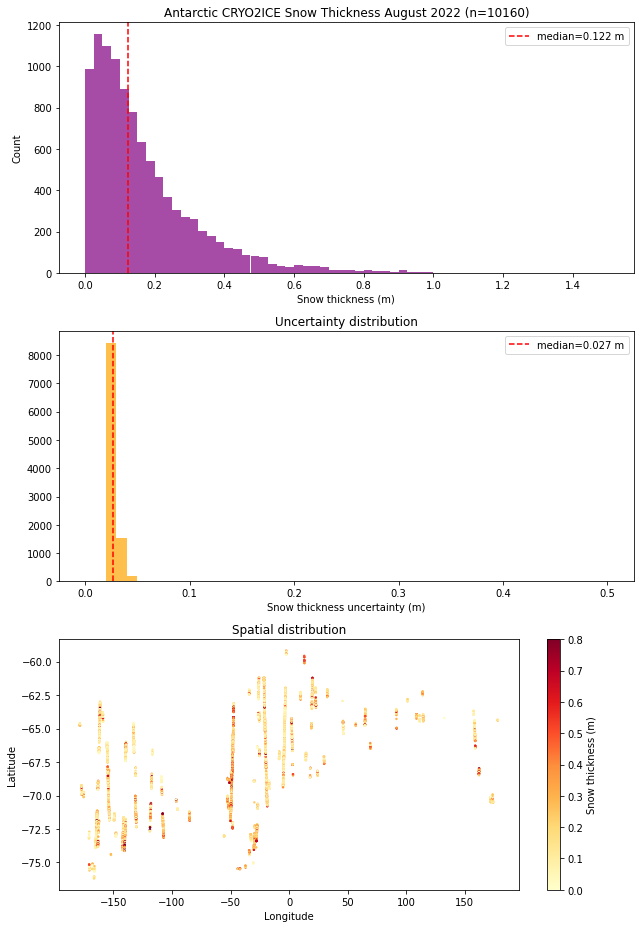

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(9, 13))

# Overall distribution
ax = axes[0]
ax.hist(hs[valid], bins=60, range=(0, 1.5), color='purple', alpha=0.7)
ax.axvline(np.nanmedian(hs[valid]), color='red', ls='--',
           label=f'median={np.nanmedian(hs[valid]):.3f} m')
ax.set_xlabel('Snow thickness (m)')
ax.set_ylabel('Count')
ax.set_title(f'Antarctic CRYO2ICE Snow Thickness August 2022 (n={valid.sum()})')
ax.legend()

# Uncertainty distribution
ax = axes[1]
ax.hist(hs_unc[valid], bins=50, range=(0, 0.5), color='orange', alpha=0.7)
ax.axvline(np.nanmedian(hs_unc[valid]), color='red', ls='--',
           label=f'median={np.nanmedian(hs_unc[valid]):.3f} m')
ax.set_xlabel('Snow thickness uncertainty (m)')
ax.set_title('Uncertainty distribution')
ax.legend()

# Spatial map
ax = axes[2]
sc = ax.scatter(df.lon[valid], df.lat[valid], c=hs[valid],
                s=2, cmap='YlOrRd', vmin=0, vmax=0.8)
plt.colorbar(sc, ax=ax, label='Snow thickness (m)')
ax.set_title('Spatial distribution')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_snow_thickness_202208.png', dpi=300)
plt.show()


In [23]:
# Density sensitivity test
print("\n=== DENSITY SENSITIVITY TEST ===")
delta_f = df['is2_fb_wm'].values - df['cs2_rfb'].values
valid = df['snow_thickness'].values > 0

for rho_test in [260, 330, 400]:
    rho_gcm3 = rho_test / 1000.0
    eta_test = (1.0 + 0.51 * rho_gcm3) ** 1.5
    hs_test = delta_f / eta_test
    hs_valid = hs_test[valid]
    print(f'rho_s = {rho_test} kg/m3: eta_s = {eta_test:.3f}, '
          f'median hs = {np.nanmedian(hs_valid):.3f} m')


=== DENSITY SENSITIVITY TEST ===
rho_s = 260 kg/m3: eta_s = 1.205, median hs = 0.128 m
rho_s = 330 kg/m3: eta_s = 1.263, median hs = 0.122 m
rho_s = 400 kg/m3: eta_s = 1.321, median hs = 0.117 m


## 4.5 Monthly and Regional Statistics

In [25]:
# Monthly statistics
print('=== Monthly Statistics ===')
for ym in sorted(df.year_month.unique()):
    mask = (df.year_month == ym) & valid
    if mask.sum() > 0:
        print(f'{ym}: n={mask.sum():>5d}  '
              f'median={np.nanmedian(hs[mask]):.3f}  '
              f'mean={np.nanmean(hs[mask]):.3f}  '
              f'std={np.nanstd(hs[mask]):.3f} m')


=== Monthly Statistics ===
202208: n=10160  median=0.122  mean=0.168  std=0.155 m


## 4.6 Save Results

In [26]:
df.to_csv(f'{HS_DIR}/snow_thickness_all_months.csv', index=False)
print(f'Saved {len(df)} rows to {HS_DIR}/snow_thickness_202208.csv')


Saved 11822 rows to /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/snow_thickness_202208.csv
